# H6 — Affect Calibration, Discrepancy, and Clinical Prediction

**Prediction:** Affective calibration and discrepancy will show a differential prediction pattern for performance versus anxiety symptoms.

**Sub-hypotheses:**
- **H6a:** Calibration and discrepancy will be approximately orthogonal: |r| < 0.15 (exploratory: r = 0.024)
- **H6b:** Discrepancy predicts STAI-State controlling for k, beta, and overcautious rate: p < 0.01, Delta-R-squared > 0.05 (exploratory: beta = 0.334, Delta-R-squared = 0.108)
- **H6c:** Calibration predicts residual overcaution: p < 0.01 (exploratory: beta = -0.007, p = 0.0007)
- **H6d:** Discrepancy predicts at least 2 additional clinical measures at p < 0.05 uncorrected
- **H6e:** Model parameters (k, beta, c_d) will NOT independently predict clinical measures: all |r| < 0.10 or p > 0.05

**What this determines:** Whether subjective affect carries clinically relevant information beyond what the computational model captures — and whether this information is specifically about miscalibration (discrepancy), not calibration accuracy.

In [1]:
# ── Imports & Data Loading (self-contained) ──
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, zscore, linregress
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.spines.right': False, 'axes.spines.top': False,
})

PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "data/exploratory_350/processed/stage5_filtered_data_20260320_191950"
OUT_DIR  = PROJECT_ROOT / "results/stats/full_analysis"
EXCLUDE  = [154, 197, 208]

# ── Load pre-computed affect metrics ──
affect = pd.read_csv(OUT_DIR / "part4_affect.csv")
merged = pd.read_csv(OUT_DIR / "part4_merged.csv")

# ── Load params ──
params = pd.read_csv(OUT_DIR / "part1_params_full.csv")

# ── Load psych ──
psych = pd.read_csv(DATA_DIR / "psych.csv")
psych = psych[~psych['subj'].isin(EXCLUDE)].copy()

# ── Load feelings for recomputation if needed ──
feelings = pd.read_csv(DATA_DIR / "feelings.csv")
feelings = feelings[~feelings['subj'].isin(EXCLUDE)].copy()

# ── Load choice data for overcaution ──
beh = pd.read_csv(DATA_DIR / "behavior.csv")
beh = beh[~beh['subj'].isin(EXCLUDE)].copy()

print(f"Affect metrics: {len(affect)} subjects")
print(f"Merged data:    {len(merged)} subjects")
print(f"Psych data:     {len(psych)} subjects")
print(f"Columns (merged): {list(merged.columns)}")

Affect metrics: 286 subjects
Merged data:    290 subjects
Psych data:     290 subjects
Columns (merged): ['subj', 'optimality_rate', 'overcautious_rate', 'overrisky_rate', 'k', 'beta', 'log_k', 'log_beta', 'c_death', 'log_cd', 'log_k_z', 'log_beta_z', 'log_cd_z', 'calibration_at', 'discrepancy', 'calibration_ca', 'disc_z', 'cal_z', 'k_group', 'b_group', 'profile']


## Compute calibration and discrepancy

**Calibration:** within-subject r(anxiety, T) — how well anxiety tracks threat.  
**Discrepancy:** mean anxiety residual after removing T-anxiety relationship — excess anxiety beyond what threat warrants.

In [2]:
# ── Compute calibration and discrepancy ──
# Use pre-computed values if available, otherwise compute from feelings
if 'calibration_at' in affect.columns and 'discrepancy' in affect.columns:
    print("Using pre-computed calibration and discrepancy from part4_affect.csv")
    cal_disc = affect[['subj', 'calibration_at', 'discrepancy']].copy()
    cal_disc.rename(columns={'calibration_at': 'calibration'}, inplace=True)
else:
    print("Computing calibration and discrepancy from feelings data...")
    anx = feelings[feelings['questionLabel'] == 'anxiety'].copy()

    # Population-level T-anxiety regression
    pop_model = smf.ols("response ~ threat", data=anx).fit()
    anx['resid'] = pop_model.resid

    records = []
    for subj, sg in anx.groupby('subj'):
        if len(sg) >= 4:
            r, _ = pearsonr(sg['threat'], sg['response'])
            disc = sg['resid'].mean()
            records.append({'subj': subj, 'calibration': r, 'discrepancy': disc})

    cal_disc = pd.DataFrame(records)

# Z-score for regressions
cal_disc['disc_z'] = zscore(cal_disc['discrepancy'])
cal_disc['cal_z']  = zscore(cal_disc['calibration'])

print(f"Computed for {len(cal_disc)} subjects")
print(f"Calibration: mean={cal_disc['calibration'].mean():.3f}, SD={cal_disc['calibration'].std():.3f}")
print(f"Discrepancy: mean={cal_disc['discrepancy'].mean():.3f}, SD={cal_disc['discrepancy'].std():.3f}")

Using pre-computed calibration and discrepancy from part4_affect.csv
Computed for 286 subjects
Calibration: mean=0.285, SD=0.340
Discrepancy: mean=0.013, SD=1.247


## H6a — Orthogonality test

**Test:** |r(calibration, discrepancy)| < 0.15 (exploratory: r = 0.024)

H6a — Calibration-Discrepancy Orthogonality
  r(calibration, discrepancy) = 0.024, p = 0.6912
  |r| = 0.024

  Verdict: PASS (threshold: |r| < 0.15)


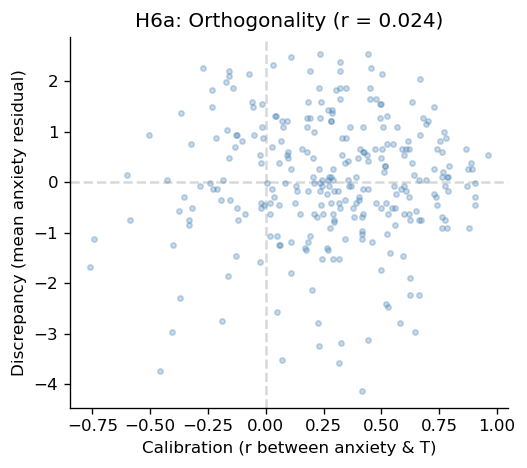

In [3]:
# ── H6a: Orthogonality ──
r_cd, p_cd = pearsonr(cal_disc['calibration'], cal_disc['discrepancy'])

print("H6a — Calibration-Discrepancy Orthogonality")
print("=" * 50)
print(f"  r(calibration, discrepancy) = {r_cd:.3f}, p = {p_cd:.4f}")
print(f"  |r| = {abs(r_cd):.3f}")
print(f"\n  Verdict: {'PASS' if abs(r_cd) < 0.15 else 'FAIL'} (threshold: |r| < 0.15)")

# Scatter
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(cal_disc['calibration'], cal_disc['discrepancy'], alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('Calibration (r between anxiety & T)')
ax.set_ylabel('Discrepancy (mean anxiety residual)')
ax.set_title(f'H6a: Orthogonality (r = {r_cd:.3f})')
ax.axhline(0, color='gray', ls='--', alpha=0.3)
ax.axvline(0, color='gray', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

## H6b — Discrepancy predicts STAI-State (with Delta-R-squared)

**Model:** `STAI_State_z ~ k_z + beta_z + overcautious_rate + discrepancy_z`  
**Test:** discrepancy p < 0.01, Delta-R-squared > 0.05

In [4]:
# ── H6b: Discrepancy → STAI-State ──
# Build regression dataset
overcautious = beh.groupby('subj').apply(lambda g: (g['choice'] == 0).mean()).reset_index()
overcautious.columns = ['subj', 'overcautious_rate']

reg_df = (params[['subj', 'log_k_z', 'log_beta_z']]
          .merge(overcautious, on='subj')
          .merge(cal_disc[['subj', 'disc_z', 'cal_z']], on='subj')
          .merge(psych[['subj', 'STAI_State']], on='subj'))

reg_df['STAI_z'] = zscore(reg_df['STAI_State'])

# Base model (without discrepancy)
m_base = smf.ols("STAI_z ~ log_k_z + log_beta_z + overcautious_rate", data=reg_df).fit()
# Full model (with discrepancy)
m_full = smf.ols("STAI_z ~ log_k_z + log_beta_z + overcautious_rate + disc_z", data=reg_df).fit()

delta_r2 = m_full.rsquared - m_base.rsquared
disc_b = m_full.params['disc_z']
disc_t = m_full.tvalues['disc_z']
disc_p = m_full.pvalues['disc_z']

print("H6b — Discrepancy predicts STAI-State")
print("=" * 55)
print(f"  Base model R²: {m_base.rsquared:.3f}")
print(f"  Full model R²: {m_full.rsquared:.3f}")
print(f"  Delta-R²:      {delta_r2:.3f}")
print(f"\n  Discrepancy: beta = {disc_b:.3f}, t = {disc_t:.3f}, p = {disc_p:.4f}")
print(f"\n  Full model coefficients:")
print(m_full.summary2().tables[1][['Coef.', 'Std.Err.', 't', 'P>|t|']].to_string())
print(f"\n  Verdict: p={'PASS' if disc_p < 0.01 else 'FAIL'}, Delta-R²={'PASS' if delta_r2 > 0.05 else 'FAIL'}")

H6b — Discrepancy predicts STAI-State
  Base model R²: 0.007
  Full model R²: 0.117
  Delta-R²:      0.110

  Discrepancy: beta = 0.335, t = 5.906, p = 0.0000

  Full model coefficients:
                      Coef.  Std.Err.         t         P>|t|
Intercept         -0.039440  0.647489 -0.060913  9.514718e-01
log_k_z           -0.085167  0.169889 -0.501307  6.165478e-01
log_beta_z         0.074065  0.148028  0.500342  6.172256e-01
overcautious_rate  0.067972  1.130646  0.060118  9.521046e-01
disc_z             0.335172  0.056749  5.906201  1.008844e-08

  Verdict: p=PASS, Delta-R²=PASS


## H6c — Calibration predicts residual overcaution

**Model:** `overcaution_residual ~ discrepancy_z + calibration_z`  
**Test:** calibration p < 0.01

H6c — Calibration predicts residual overcaution
                  Coef.  Std.Err.             t     P>|t|
Intercept -2.917425e-16  0.002486 -1.173645e-13  1.000000
disc_z     3.583592e-03  0.002486  1.441234e+00  0.150624
cal_z     -6.960180e-03  0.002486 -2.799217e+00  0.005475

  Calibration: beta = -0.0070, t = -2.799, p = 0.0055

  Verdict: PASS (threshold: p < 0.01)


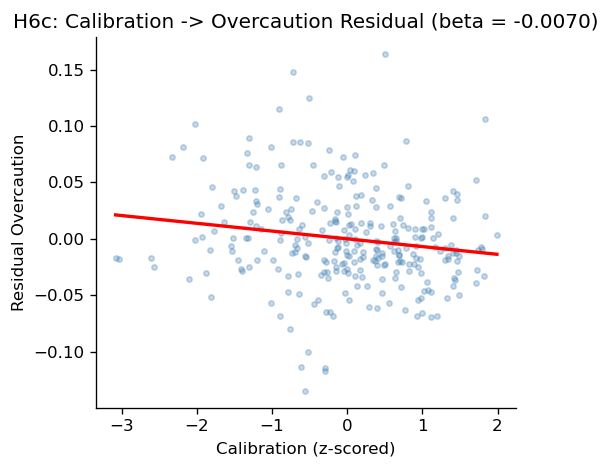

In [5]:
# ── H6c: Calibration → residual overcaution ──
# Compute residual overcaution: overcautious_rate after removing k, beta, k*beta
oc_df = (params[['subj', 'log_k_z', 'log_beta_z']]
         .merge(overcautious, on='subj')
         .merge(cal_disc[['subj', 'disc_z', 'cal_z']], on='subj'))

m_oc_base = smf.ols("overcautious_rate ~ log_k_z * log_beta_z", data=oc_df).fit()
oc_df['oc_resid'] = m_oc_base.resid

# Predict residual overcaution from calibration and discrepancy
m_h6c = smf.ols("oc_resid ~ disc_z + cal_z", data=oc_df).fit()

cal_b = m_h6c.params['cal_z']
cal_t = m_h6c.tvalues['cal_z']
cal_p = m_h6c.pvalues['cal_z']

print("H6c — Calibration predicts residual overcaution")
print("=" * 55)
print(m_h6c.summary2().tables[1][['Coef.', 'Std.Err.', 't', 'P>|t|']].to_string())
print(f"\n  Calibration: beta = {cal_b:.4f}, t = {cal_t:.3f}, p = {cal_p:.4f}")
print(f"\n  Verdict: {'PASS' if cal_p < 0.01 else 'FAIL'} (threshold: p < 0.01)")

# Scatter
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(oc_df['cal_z'], oc_df['oc_resid'], alpha=0.3, s=10, color='steelblue')
sl, inter = np.polyfit(oc_df['cal_z'], oc_df['oc_resid'], 1)
x_line = np.linspace(oc_df['cal_z'].min(), oc_df['cal_z'].max(), 50)
ax.plot(x_line, sl * x_line + inter, 'r-', lw=2)
ax.set_xlabel('Calibration (z-scored)')
ax.set_ylabel('Residual Overcaution')
ax.set_title(f'H6c: Calibration -> Overcaution Residual (beta = {cal_b:.4f})')
plt.tight_layout()
plt.show()

## H6d — Clinical scan: discrepancy predicts additional symptom measures

**Test:** Discrepancy correlates with at least 2 additional clinical measures at p < 0.05 uncorrected

In [6]:
# ── H6d: Clinical scan — discrepancy → all measures ──
clinical_measures = ['OASIS_Total', 'STICSA_Total', 'PHQ9_Total',
                     'DASS21_Anxiety', 'DASS21_Stress', 'DASS21_Depression',
                     'STAI_State', 'STAI_Trait']

scan_df = cal_disc[['subj', 'disc_z']].merge(psych, on='subj')

print("H6d — Discrepancy → Clinical Measures")
print("=" * 60)
print(f"  {'Measure':<22} {'r':>7} {'p':>10} {'sig':>5}")
print(f"  {'-'*47}")

sig_count = 0
for measure in clinical_measures:
    if measure in scan_df.columns:
        valid = scan_df.dropna(subset=[measure, 'disc_z'])
        if len(valid) > 10:
            r, p = pearsonr(valid['disc_z'], valid[measure])
            star = '*' if p < 0.05 else ''
            if p < 0.05:
                sig_count += 1
            print(f"  {measure:<22} {r:>7.3f} {p:>10.4f} {star:>5}")
    else:
        print(f"  {measure:<22}  — not found")

print(f"\n  Significant at p < 0.05: {sig_count}")
print(f"  Verdict: {'PASS' if sig_count >= 2 else 'FAIL'} (threshold: >= 2 significant)")

H6d — Discrepancy → Clinical Measures
  Measure                      r          p   sig
  -----------------------------------------------
  OASIS_Total              0.204     0.0005     *
  STICSA_Total             0.264     0.0000     *
  PHQ9_Total               0.204     0.0005     *
  DASS21_Anxiety           0.251     0.0000     *
  DASS21_Stress            0.227     0.0001     *
  DASS21_Depression        0.211     0.0003     *
  STAI_State               0.326     0.0000     *
  STAI_Trait              -0.219     0.0002     *

  Significant at p < 0.05: 8
  Verdict: PASS (threshold: >= 2 significant)


## H6e — Model parameters do NOT predict clinical measures

**Test:** All |r| < 0.10 or p > 0.05 for each of k, beta, c_d vs each clinical measure

In [7]:
# ── H6e: Model params → clinical (expect all null) ──
param_cols = ['log_k_z', 'log_beta_z', 'log_cd_z']
param_labels = ['k', 'beta', 'c_d']

clin_df = params[['subj'] + param_cols].merge(psych, on='subj')

print("H6e — Model Parameters → Clinical Measures")
print("=" * 70)
print(f"  {'Measure':<22}", end='')
for pl in param_labels:
    print(f"  {pl:>12}", end='')
print()
print(f"  {'-'*58}")

any_sig = False
for measure in clinical_measures:
    if measure not in clin_df.columns:
        continue
    valid = clin_df.dropna(subset=[measure])
    print(f"  {measure:<22}", end='')
    for pc in param_cols:
        if len(valid) > 10:
            r, p = pearsonr(valid[pc], valid[measure])
            star = '*' if p < 0.05 else ''
            if p < 0.05 and abs(r) >= 0.10:
                any_sig = True
            print(f"  r={r:>5.3f}{star:1s}    ", end='')
        else:
            print(f"  {'—':>12}", end='')
    print()

print(f"\n  Any significant (p<0.05 AND |r|>=0.10): {any_sig}")
print(f"  Verdict: {'PASS' if not any_sig else 'FAIL'} (expect: all null)")

H6e — Model Parameters → Clinical Measures
  Measure                            k          beta           c_d
  ----------------------------------------------------------
  OASIS_Total             r=-0.104       r=0.017       r=-0.025     
  STICSA_Total            r=-0.048       r=-0.004       r=0.002     
  PHQ9_Total              r=-0.070       r=-0.008       r=0.057     
  DASS21_Anxiety          r=-0.044       r=-0.056       r=0.014     
  DASS21_Stress           r=-0.092       r=0.003       r=0.023     
  DASS21_Depression       r=-0.059       r=-0.003       r=0.083     
  STAI_State              r=-0.025       r=0.079       r=0.029     
  STAI_Trait              r=-0.004       r=-0.077       r=-0.012     

  Any significant (p<0.05 AND |r|>=0.10): False
  Verdict: PASS (expect: all null)


## Summary

| Test | Prediction | Result | Verdict |
|------|-----------|--------|---------|
| H6a (orthogonality) | \|r\| < 0.15 | _fill_ | _PASS/FAIL_ |
| H6b (discrepancy → STAI) | p < 0.01, Delta-R-squared > 0.05 | _fill_ | _PASS/FAIL_ |
| H6c (calibration → overcaution) | p < 0.01 | _fill_ | _PASS/FAIL_ |
| H6d (discrepancy → clinical scan) | >= 2 measures at p < 0.05 | _fill_ | _PASS/FAIL_ |
| H6e (params → clinical) | all null | _fill_ | _PASS/FAIL_ |

**Interpretation:** If H6a-e pass, the affect system provides clinically relevant information that the computational model (k, beta, c_d) cannot capture. Specifically:
- **Discrepancy** (excess anxiety beyond threat) predicts trait anxiety and clinical symptoms — this is a metacognitive signal about emotional miscalibration.
- **Calibration** (anxiety-threat tracking accuracy) predicts residual overcaution — this links emotional accuracy to decision quality.
- **Model parameters** do not predict clinical outcomes on their own — computational efficiency in the task is not pathological; emotional *miscalibration* is.

This establishes that metacognition (how well you track your own emotional responses to threat) is the strongest bridge between task behavior and clinical symptoms.